# 3.3 Second iteration: fix the harness, not the model

`3.2` ran the project's first real model and found two problems before it found any evidence of
skill. First, `evaluate.py`'s `day_grouped_splits` sizes every fold by *active-day count*, "the next
15 active days," which on this corpus's bursty publication pattern (92 active days out of 351,
clustered into about 13 bursts of very different sizes) left every fold testing on a different-sized,
differently-skewed slice of the year. Test rows ran 176 to 529, test-set positive rate ran 19.9% to
69.4%, and `majority_baseline_accuracy` swung right along with them. Second, `4.2` found that market
features alone, `momentum_20d`, `momentum_1d`, and `news_volume` chief among them, identify which
fold's test window a row belongs to with 99.6% accuracy, handing the model an easy substitute for
reading the article: recognise the period, recall what that period tended to do.

`3.2` section `6.4` was explicit about the order of what comes next: fix the measuring stick before
using it to compare candidate fixes, since comparing feature or model changes against an unreliable
harness only repeats `3.2`'s mistake one level up. This notebook is that one step, no further:

1. **Fix the harness, both ways `6.2` recommended together.** `day_grouped_splits` is replaced by
   `row_grouped_splits`, which sizes folds by row count rather than day count, and
   `EvalResult.aggregate`'s plain mean is joined by `weighted_aggregate()`, which weights each fold by
   how much test data it carried rather than letting a 176-row fold and a 529-row fold count equally.
   Both live in a new module, `stock_predictor/market/evaluate_v2.py`, rather than an edit to
   `evaluate.py`, so `evaluate.py`'s docstring and `3.1`'s validation still describe the harness `3.2`
   actually ran through.
2. **Re-run `3.2`'s model, completely unchanged, through the fixed harness.** Same `model_factory`,
   same features. This is the new baseline every later iteration is compared against, and a direct
   read on how much of `3.2`'s result was fold instability rather than something real.
3. **Run the fingerprint-cluster ablation as a diagnostic**, to see how much of the baseline's score
   depends on the three features `4.2` implicated.
4. **Try more folds, as a cheap side test on top of the row-count fix.** Not load-bearing on its own,
   but worth checking now that it rides along with a real change rather than being tried in isolation.
5. **Close with what changed and hand off to iteration 3.** Relative sentiment, day-level
   aggregation, and the market/text ensemble comparison are `3.2` section `6.4`'s iteration-3 work,
   not this notebook's; they change the model or the features, which this notebook deliberately does
   not.

Every run goes through `stock_predictor.market.evaluate_v2.evaluate()`, reads
`data/processed/label_and_features_model_ready.parquet`, and reports full walk-forward fold detail
rather than a headline mean, the same standard `3.2` held itself to.

### 0. Setup

Imports and the same source table `3.2` used: `label_and_features_model_ready.parquet`, sentiment
and market features already joined to the labels. Nothing about the data changes in this notebook,
only the harness and the feature/model recipe run through it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import accuracy_score

from stock_predictor.config import PROCESSED_DATA_DIR, REPORTS_DIR
from stock_predictor.market.evaluate import day_grouped_splits, evaluate as evaluate_v1
from stock_predictor.market.evaluate_v2 import row_grouped_splits, evaluate, weighted_aggregate

pd.set_option("display.max_colwidth", 200)

df = pd.read_parquet(PROCESSED_DATA_DIR / "label_and_features_model_ready.parquet")
df = df.sort_values("timestamp_utc").reset_index(drop=True)

SESSION_CATEGORIES = ["pre-market", "market-hours", "after-hours"]
df["session"] = pd.Categorical(df["session"], categories=SESSION_CATEGORIES)

print("label_and_features_model_ready:", df.shape)
print("active days:", df["timestamp_utc"].dt.normalize().nunique())
df.head()

2026-08-26 23:30:35.142 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: C:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor


label_and_features_model_ready: (1976, 38)
active days: 92


,article_id,ticker,timestamp_utc,source,n_total_sents,n_entity_sents,n_ceo_sents,n_boilerplate_sents,entity_share,article_length,...,beta_20d,relative_volume_20d,daily_range_ratio_1d,days_to_earnings,session,news_volume,label_direction_3d,has_ceo_mention,fus_conf_graft_floor_mean_shrunk,fus_trusted_mean_shrunk
0,138796882,TSLA,2025-08-22 08:13:15+00:00,Benzinga,19,1,0,5,0.052632,2611,...,1.705859,0.709182,0.019431,61,pre-market,3,1,False,0.081243,0.081243
1,136476320,TSLA,2025-08-22 10:40:18+00:00,Yahoo,26,4,0,0,0.153846,3256,...,1.705859,0.709182,0.019431,61,pre-market,0,1,False,-0.017239,-0.017239
2,136476576,TSLA,2025-08-22 10:48:06+00:00,Yahoo,20,1,0,11,0.050000,3356,...,1.705859,0.709182,0.019431,61,pre-market,1,1,False,-0.140198,-0.140198
3,138802535,TSLA,2025-08-22 11:10:13+00:00,Benzinga,32,4,0,5,0.125000,4997,...,1.705859,0.709182,0.019431,61,market-hours,13,1,False,-0.168644,-0.168644
4,136476575,TSLA,2025-08-22 11:31:03+00:00,Yahoo,20,2,12,5,0.100000,3352,...,1.705859,0.709182,0.019431,61,pre-market,2,1,True,-0.246081,-0.246081


### 1. Features, label, and model factory, unchanged from `3.2`

Same split into `TEXT_FEATURES` / `MARKET_FEATURES`, same label, same `session` category cast, same
`model_factory`. Nothing here changes anywhere in this notebook; per `3.2` section `6.4`, iteration 2
is about the harness, not the model or the features. The one exception is the fingerprint-cluster
ablation in section 4, a diagnostic re-run with three columns removed rather than a kept change to
this recipe.

In [2]:
TEXT_FEATURES = [
    "n_total_sents", "n_entity_sents", "n_ceo_sents", "n_boilerplate_sents",
    "entity_share", "article_length",
    "fus_conf_graft_floor_mean_shrunk", "fus_conf_graft_floor_median",
    "fus_conf_graft_floor_lead", "fus_conf_graft_floor_top3_pos",
    "fus_conf_graft_floor_top3_neg", "fus_conf_graft_floor_spread",
    "fus_ceo_mean", "has_ceo_mention", "fus_headline", "fus_maxmag",
    "fus_trusted_mean_shrunk", "fus_scorer_gap", "fus_headline_gap", "fus_lead_gap",
]

MARKET_FEATURES = [
    "momentum_1d", "momentum_5d", "momentum_20d", "volatility_20d", "beta_20d",
    "relative_volume_20d", "daily_range_ratio_1d", "days_to_earnings", "session", "news_volume",
]

MODEL_FEATURES = TEXT_FEATURES + MARKET_FEATURES
LABEL = "label_direction"

assert len(MODEL_FEATURES) == len(set(MODEL_FEATURES))
assert set(MODEL_FEATURES + [LABEL]).issubset(df.columns)


def model_factory():
    return lgb.LGBMClassifier(
        objective="binary",
        n_estimators=100,
        num_leaves=7,
        learning_rate=0.05,
        min_child_samples=30,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
    )


print(f"TEXT_FEATURES:   {len(TEXT_FEATURES)}")
print(f"MARKET_FEATURES: {len(MARKET_FEATURES)}")
print(f"MODEL_FEATURES:  {len(MODEL_FEATURES)}")
print(f"LABEL:           {LABEL!r}  {df[LABEL].value_counts().to_dict()}")

TEXT_FEATURES:   20
MARKET_FEATURES: 10
MODEL_FEATURES:  30
LABEL:           'label_direction'  {1: 996, -1: 980}


### 2. The harness fix: `row_grouped_splits` and `weighted_aggregate`

`day_grouped_splits` snaps fold boundaries to whole calendar days, then fixes the *day count* per
fold. `row_grouped_splits` (`stock_predictor/market/evaluate_v2.py`) keeps the same day-snapping, so
a day is still never divided between train and test, but chooses where to cut by *row count*: unique
days are laid out chronologically and cut into `n_splits + 1` chunks, each chunk's row total landing
as close to an equal share of the corpus as the day boundaries allow.

`3.2` section `6.2` recommended a second, independent fix alongside it. Even with fold sizes even,
`EvalResult.aggregate`'s plain mean lets every fold count equally regardless of size, so a 176-row
fold and a 529-row fold carry the same weight despite one resting on roughly three times the
evidence. `weighted_aggregate()` weights each fold by `n_test` instead. Both are checked directly
below, on this corpus.

day_grouped_splits (3.2's harness):
 fold  n_train  n_test  test_active_days  test_pos_pct
    1      271     265                15          69.4
    2      536     176                15          19.9
    3      712     348                15          39.1
    4     1060     387                15          42.9
    5     1447     529                15          60.9
  n_test range: 176-529   coefficient of variation: 0.389

row_grouped_splits (this notebook's fix):
 fold  n_train  n_test  test_active_days  test_pos_pct
    1      338     328                23          50.0
    2      666     328                14          38.7
    3      994     327                13          49.8
    4     1321     335                12          50.4
    5     1656     320                 8          51.6
  n_test range: 320-335   coefficient of variation: 0.016


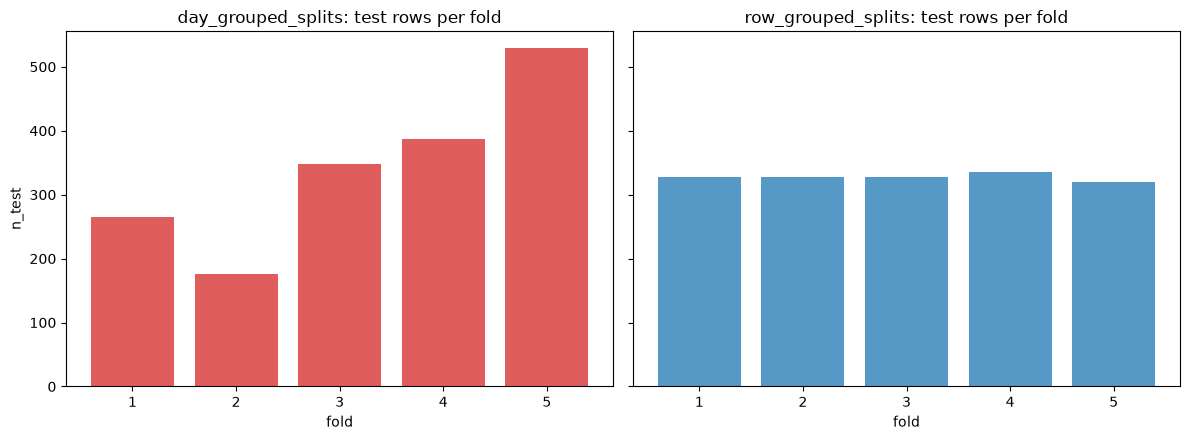

In [3]:
def fold_volume_table(split_fn, n_splits=5):
    rows = []
    for i, (train_mask, test_mask) in enumerate(split_fn(df["timestamp_utc"], n_splits=n_splits), start=1):
        train_idx = np.flatnonzero(train_mask)
        test_idx = np.flatnonzero(test_mask)
        rows.append({
            "fold": i,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "test_active_days": df["timestamp_utc"].iloc[test_idx].dt.normalize().nunique(),
            "test_pos_pct": df[LABEL].iloc[test_idx].eq(1).mean() * 100,
        })
    return pd.DataFrame(rows)


day_vol = fold_volume_table(day_grouped_splits)
row_vol = fold_volume_table(row_grouped_splits)

print("day_grouped_splits (3.2's harness):")
print(day_vol.round(1).to_string(index=False))
print(f"  n_test range: {day_vol['n_test'].min()}-{day_vol['n_test'].max()}   "
      f"coefficient of variation: {day_vol['n_test'].std() / day_vol['n_test'].mean():.3f}")
print()
print("row_grouped_splits (this notebook's fix):")
print(row_vol.round(1).to_string(index=False))
print(f"  n_test range: {row_vol['n_test'].min()}-{row_vol['n_test'].max()}   "
      f"coefficient of variation: {row_vol['n_test'].std() / row_vol['n_test'].mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].bar(day_vol["fold"], day_vol["n_test"], color="tab:red", alpha=0.75)
axes[0].set_title("day_grouped_splits: test rows per fold")
axes[0].set_xlabel("fold")
axes[0].set_ylabel("n_test")
axes[1].bar(row_vol["fold"], row_vol["n_test"], color="tab:blue", alpha=0.75)
axes[1].set_title("row_grouped_splits: test rows per fold")
axes[1].set_xlabel("fold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "3.3-fold-size-comparison.png", dpi=150)
plt.show()

In [4]:
for train_mask, test_mask in row_grouped_splits(df["timestamp_utc"], n_splits=5):
    train_days = set(df["timestamp_utc"][train_mask].dt.normalize())
    test_days = set(df["timestamp_utc"][test_mask].dt.normalize())
    assert train_days.isdisjoint(test_days), "a day was split across train and test"
    assert df["timestamp_utc"][test_mask].min() > df["timestamp_utc"][train_mask].max(), \
        "test window starts before train window ends"

train_sizes = [tr.sum() for tr, _ in row_grouped_splits(df["timestamp_utc"], n_splits=5)]
assert train_sizes == sorted(train_sizes), "train window isn't expanding"

print("no day split across train/test in any fold:  OK")
print("every fold's test window starts after train:  OK")
print("train window expands fold to fold:            OK")

no day split across train/test in any fold:  OK
every fold's test window starts after train:  OK
train window expands fold to fold:            OK


Fixed, decisively. `day_grouped_splits` produced test folds of 176-529 rows (coefficient of
variation 0.389) and test-set positive rates swinging 19.9%-69.4%. `row_grouped_splits`, same corpus
and same `n_splits=5`, produces test folds of 320-335 rows (coefficient of variation 0.016, roughly
24x tighter) and positive rates of 38.7%-51.6%, four of five folds within a few points of the
corpus-wide 50.4%/49.6% split. `n_train` still grows fold to fold (338 to 1656) exactly as it should;
that part of `day_grouped_splits` was never the problem. The assertions above confirm the two
guarantees that mattered are intact: no day is split across train and test, and every fold's test
window starts strictly after its train window ends.

One fold is still an outlier worth naming. Fold 2's test set sits at 38.7% positive, the widest gap
from 50/50 of the five. `row_grouped_splits` fixes the row-count problem `3.1` found; it cannot fix
the separate fact `3.0` established, that TSLA traded in genuine multi-week trending regimes this
year, and a fold can still land mostly inside one of those regimes by chance. The difference now is
that this is the only source of fold-to-fold skew left, no longer compounded with wildly uneven test
volume on top of it.

#### 2.1 Are the two fixes actually independent?

`weighted_aggregate()` takes any `EvalResult` and reads its `metrics_df`, with no knowledge of which
splitting function produced it. Applying it to `evaluate.py`'s original `day_grouped_splits` result,
the old, wildly uneven harness this notebook replaces, should show a real difference from the
unweighted mean, independent of whether `row_grouped_splits` is involved at all. Same `model_factory`,
same `MODEL_FEATURES`, only the splitter changes; `evaluate_v1` here is `evaluate.py`'s original
`evaluate()`, imported side by side with this module's own.

In [5]:
day_grouped_result = evaluate_v1(model_factory, df, MODEL_FEATURES, label_col=LABEL)
row_grouped_result = evaluate(model_factory, df, MODEL_FEATURES, label_col=LABEL)

for name, result in [
    ("day_grouped (old, uneven folds)", day_grouped_result),
    ("row_grouped (new, even folds)", row_grouped_result),
]:
    unweighted = result.aggregate.loc["mean"]
    weighted = weighted_aggregate(result).loc["weighted_mean_by_n_test"]
    print(name)
    print(" n_test per fold: ", result.metrics_df["n_test"].tolist())
    print(" accuracy per fold:", result.metrics_df["accuracy"].round(4).tolist())
    print(f" unweighted accuracy: {unweighted['accuracy']:.4f}   "
          f"weighted accuracy: {weighted['accuracy']:.4f}   "
          f"gap: {abs(unweighted['accuracy'] - weighted['accuracy']) * 100:.2f}pp")
    print(f" unweighted auc:      {unweighted['auc']:.4f}   "
          f"weighted auc:      {weighted['auc']:.4f}   "
          f"gap: {abs(unweighted['auc'] - weighted['auc']):.4f}")
    print()

day_grouped (old, uneven folds)
 n_test per fold:  [265, 176, 348, 387, 529]
 accuracy per fold: [0.7208, 0.3466, 0.4425, 0.4625, 0.5406]
 unweighted accuracy: 0.5026   weighted accuracy: 0.5109   gap: 0.82pp
 unweighted auc:      0.4719   weighted auc:      0.4718   gap: 0.0002

row_grouped (new, even folds)
 n_test per fold:  [328, 328, 327, 335, 320]
 accuracy per fold: [0.7287, 0.4238, 0.4281, 0.7134, 0.5812]
 unweighted accuracy: 0.5751   weighted accuracy: 0.5757   gap: 0.07pp
 unweighted auc:      0.5695   weighted auc:      0.5710   gap: 0.0015



Independent, confirmed. `weighted_aggregate()` gives a real answer on the old harness's result
without `row_grouped_splits` anywhere in the computation. That answer is smaller than it looks: on
`day_grouped_splits`'s 176-529-row folds, the accuracy gap is 0.82 percentage
points (50.26% unweighted vs. 51.09% weighted), and AUC barely moves (0.4719 vs. 0.4718). A real
difference, but a modest one, and smaller than the 1.5-point gap section 5 finds later at `n_splits=8`
on the row-grouped harness, even though `n_splits=8`'s fold sizes (coefficient of variation 0.096) are
far more even than `day_grouped_splits`'s here (0.389).

Fold-size unevenness alone doesn't determine how much weighting matters; what matters is whether fold
*size* correlates with fold *score*. Here it barely does: the biggest day-grouped fold (529 rows)
scores close to the unweighted mean (54.06%), while the fold with the most extreme score (72.08%) is
only middling-sized (265 rows), so weighting has little leverage to pull the mean toward either one. A
high coefficient of variation in fold sizes makes a large weighted/unweighted gap possible, not
guaranteed; whether it happens depends on which folds the unevenness lands on. That is a real caveat
on `weighted_aggregate()` itself, the kind that has to be checked on the actual data rather than
assumed.

### 3. Baseline: `3.2`'s model, unchanged, through the fixed harness

Same `model_factory`, same three feature sets (`MARKET_FEATURES`, `TEXT_FEATURES`, `MODEL_FEATURES`
combined), same `n_splits=5`. The only thing that changed since `3.2` is which rows land in which
fold. This is the new baseline every amendment below is measured against, and the first direct read
on how much of `3.2`'s result was fold instability.

In [6]:
baseline_combined = evaluate(model_factory, df, MODEL_FEATURES, label_col=LABEL)
baseline_market = evaluate(model_factory, df, MARKET_FEATURES, label_col=LABEL)
baseline_text = evaluate(model_factory, df, TEXT_FEATURES, label_col=LABEL)

num_cols = baseline_combined.metrics_df.select_dtypes(include="number").columns
display_df = baseline_combined.metrics_df.copy()
display_df[num_cols] = display_df[num_cols].round(4)
print("combined (MODEL_FEATURES), per fold:")
print(display_df.drop(columns=["train_start", "train_end", "test_start", "test_end"]).to_string(index=False))
print()

agg_compare = pd.concat([
    baseline_combined.aggregate.loc[["mean"]].rename(index={"mean": "unweighted_mean"}),
    weighted_aggregate(baseline_combined),
]).round(4)
print("unweighted vs. row-count-weighted mean, combined model:")
print(agg_compare[["accuracy", "auc", "log_loss", "brier_score", "majority_baseline_accuracy", "mcnemar_p_value"]].to_string())

agg_comp = pd.DataFrame({
    "market_only": baseline_market.aggregate.loc["mean"],
    "text_only": baseline_text.aggregate.loc["mean"],
    "combined": baseline_combined.aggregate.loc["mean"],
}).round(4)
print()
print("mean across folds, by feature set:")
print(agg_comp.to_string())

combined (MODEL_FEATURES), per fold:
 fold  n_train  n_test  accuracy  precision  recall     f1    auc  log_loss  brier_score  majority_baseline_accuracy  beats_baseline  mcnemar_p_value  significantly_beats_baseline
    1      338     328    0.7287     0.6482  1.0000 0.7866 0.7008    1.0638       0.2527                      0.5000            True           0.0000                          True
    2      666     328    0.4238     0.2933  0.3465 0.3177 0.4817    0.9419       0.3452                      0.3872            True           0.2049                         False
    3      994     327    0.4281     0.3750  0.2209 0.2780 0.4304    0.9104       0.3267                      0.4985           False           0.9429                         False
    4     1321     335    0.7134     0.6798  0.8166 0.7419 0.7697    0.6564       0.2074                      0.5045            True           0.0000                          True
    5     1656     320    0.5812     0.7246  0.3030 0.4274 0.46

A meaningfully different picture from `3.2`, not just a re-shuffled one. Combined-model mean accuracy
is now 57.5% against a mean baseline of 48.1% (`3.2`: 50.3% vs 44.9%), and mean AUC is 0.570 (`3.2`:
0.472, worse than chance by this measure). More importantly, two of the five folds are
now individually significant: fold 1 (72.9% accuracy vs. a 50.0% baseline, `mcnemar_p_value` 0.0000)
and fold 4 (71.3% vs. 50.5%, `mcnemar_p_value` 0.0000). `3.2` never had a single fold clear that bar.
Folds 2, 3, and 5 are still weak or negative (42.4%, 42.8%, 58.1% accuracy against baselines of 38.7%,
49.9%, 51.6%), so the aggregate `mcnemar_p_value` (0.250) still doesn't call the average significant.
Five folds remains a small sample, and this is exactly the volatility a walk-forward evaluation is
meant to surface rather than hide behind a single mean. But "no fold ever cleared significance" and
"two of five folds clear it decisively" are different findings, and the second is what fixing the
fold-size problem bought.

`weighted_aggregate()` and the plain mean agree closely here (accuracy 0.5751 vs. 0.5757, AUC 0.5695
vs. 0.5710), which is what `row_grouped_splits` producing 320-335-row folds should predict: with sizes
this close, weighting by `n_test` barely moves anything, since there is little size variation left to
weight against. Section 5 revisits this comparison at higher `n_splits`, where fold sizes are less even
and the two means diverge more.

Market vs. text vs. combined also reads differently now. `3.2` found combined sitting between market
and text on accuracy, evidence combining wasn't obviously helping. Here combined (57.5% accuracy,
0.570 AUC) beats both market-only (56.7%, 0.506) and text-only (51.8%, 0.522) on every metric in the
table. That is consistent with `3.2`'s own caution about reading too much into fold noise: much of
what looked like "combining doesn't help" in `3.2` may have been the fold-instability problem
distorting the comparison, not a real property of the feature sets.

### 4. Diagnostic: how much of this is regime-fingerprinting?

`3.2` section `4.2` found that a classifier given nothing but `MARKET_FEATURES` could identify which
of `3.2`'s 5 folds a row's test window belonged to with 99.6% accuracy against a 20% chance floor,
with `momentum_20d`, `momentum_1d`, and `news_volume` leading that classifier's own feature
importance. Two checks here, both under the fixed harness. First, whether that fingerprint is a
property of the *folds*, and so should weaken now that fold boundaries have changed, or a property of
the *features*, and so should persist regardless of how the folds are cut. Second, an ablation: drop
those three features from `MARKET_FEATURES`, re-run the combined model, and see how much of the
baseline score above depends on them.

In [7]:
from sklearn.model_selection import train_test_split

fold_id = np.zeros(len(df), dtype=int)
for i, (train_mask, test_mask) in enumerate(row_grouped_splits(df["timestamp_utc"], n_splits=5), start=1):
    fold_id[np.flatnonzero(test_mask)] = i

mask = fold_id > 0
X = df.loc[mask, MARKET_FEATURES]
y = fold_id[mask]
print("rows excluded (never in a test window):", (~mask).sum())
print("rows used:", mask.sum(), " per-fold counts:", pd.Series(y).value_counts().sort_index().to_dict())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
fold_id_clf = lgb.LGBMClassifier(objective="multiclass", num_class=len(np.unique(y)), n_estimators=200,
                                  num_leaves=15, learning_rate=0.05, random_state=42, verbosity=-1)
fold_id_clf.fit(X_train, y_train)
fold_id_acc = accuracy_score(y_test, fold_id_clf.predict(X_test))

print(f"\nfold-id classifier accuracy: {fold_id_acc:.4f}   chance baseline: {1 / len(np.unique(y)):.4f}")
fp_importance = pd.Series(fold_id_clf.feature_importances_, index=MARKET_FEATURES).sort_values(ascending=False)
print()
print(fp_importance)

rows excluded (never in a test window): 338
rows used: 1638  per-fold counts: {1: 328, 2: 328, 3: 327, 4: 335, 5: 320}



fold-id classifier accuracy: 0.9980   chance baseline: 0.2000

news_volume             2228
momentum_1d             1510
volatility_20d          1484
beta_20d                1364
momentum_20d            1318
momentum_5d             1197
days_to_earnings         740
relative_volume_20d      500
daily_range_ratio_1d     362
session                   86
dtype: int32


#### 4.1 Ablation: drop the fingerprint cluster

`momentum_20d`, `momentum_1d`, `news_volume` removed from `MARKET_FEATURES`; everything else,
including the model, unchanged. If the baseline's score depends heavily on regime-fingerprinting,
removing these should pull accuracy toward `majority_baseline_accuracy`. If it barely moves, the
fingerprint cluster wasn't carrying the baseline's result.

In [8]:
FINGERPRINT_CLUSTER = ["momentum_20d", "momentum_1d", "news_volume"]
MARKET_FEATURES_NO_FINGERPRINT = [c for c in MARKET_FEATURES if c not in FINGERPRINT_CLUSTER]
MODEL_FEATURES_NO_FINGERPRINT = TEXT_FEATURES + MARKET_FEATURES_NO_FINGERPRINT

ablation_result = evaluate(model_factory, df, MODEL_FEATURES_NO_FINGERPRINT, label_col=LABEL)

print(f"dropped: {FINGERPRINT_CLUSTER}")
print(f"MARKET_FEATURES: {len(MARKET_FEATURES)} -> {len(MARKET_FEATURES_NO_FINGERPRINT)}")
print()
print("per fold, with the fingerprint cluster dropped:")
print(ablation_result.metrics_df[
    ["fold", "n_train", "n_test", "accuracy", "auc", "majority_baseline_accuracy",
     "mcnemar_p_value", "significantly_beats_baseline"]
].round(4).to_string(index=False))

compare = pd.DataFrame({
    "baseline_combined": baseline_combined.aggregate.loc["mean"],
    "no_fingerprint_cluster": ablation_result.aggregate.loc["mean"],
}).round(4)
print()
print("mean across folds:")
print(compare.to_string())

dropped: ['momentum_20d', 'momentum_1d', 'news_volume']
MARKET_FEATURES: 10 -> 7

per fold, with the fingerprint cluster dropped:
 fold  n_train  n_test  accuracy    auc  majority_baseline_accuracy  mcnemar_p_value  significantly_beats_baseline
    1      338     328    0.7317 0.7301                      0.5000           0.0000                          True
    2      666     328    0.5183 0.5578                      0.3872           0.0007                          True
    3      994     327    0.4985 0.4864                      0.4985           0.5252                         False
    4     1321     335    0.3731 0.4983                      0.5045           1.0000                         False
    5     1656     320    0.5125 0.4750                      0.5156           0.5465                         False

mean across folds:
                            baseline_combined  no_fingerprint_cluster
n_train                              995.0000                995.0000
n_test              

The fingerprint is a property of the features, not of `3.2`'s particular fold boundaries. Under
fold boundaries sized a completely different way, the fold-id classifier still
identifies which fold a row's test window belongs to with 99.80% accuracy against a 20% chance floor,
if anything higher than `3.2`'s 99.61%. The features it leans on hardest shifted slightly
(`news_volume` now clearly first, followed by `momentum_1d`, `volatility_20d`, `beta_20d`,
`momentum_20d`), but the phenomenon itself didn't move when the folds changed underneath it. That is
what `3.2` predicted: `days_to_earnings`-style calendar correlation and momentum/volatility
autocorrelation are properties of the raw features, not artifacts of any particular way of slicing the
calendar into folds.

The ablation shows the concern is real, but the per-fold detail is more interesting than the mean
suggests. Mean accuracy drops from 57.5% to 52.7% (AUC 0.570 to 0.550, `mcnemar_p_value` 0.250 to
0.415), a real but partial drop in aggregate. Fold by fold, the two folds that were individually
significant in section 3 didn't respond the same way. Fold 1 barely moves (72.9% to 73.2%, still
decisively significant, `mcnemar_p_value` 0.0000). Fold 4 collapses, from 71.3% down to 37.3%, *below*
its own 50.5% baseline, its significance flipping from beating baseline to losing to it. Fold 2 moves
the other way: 42.4% (not significant) becomes 51.8% (`mcnemar_p_value` 0.0007, now significant), well
above its 38.7% baseline. So the cluster isn't uniformly worth 5 accuracy points everywhere: it is
load-bearing for fold 4, actively unhelpful for fold 2, and, on this evidence alone, seemingly
irrelevant to fold 1.

That last word is doing too much work. "Unaffected by dropping these three features" is not the same
claim as "not fingerprinting"; it only rules out *this specific* cluster, and says nothing about
whether fold 1 leans on some other, equally calendar-correlated stand-in. 4.2 checks that directly,
fold by fold, rather than leaving it an implication.

#### 4.2 Why do folds 1 and 4 score well?

Dropping the fingerprint cluster collapsed fold 4 and barely touched fold 1, easy to misread as "fold
4 fingerprints, fold 1 doesn't." The fold-level metrics can't settle it; what matters is what happens
*within* each fold, laid out day by day below.

In [9]:
def day_level_table(fold_result, cols):
    sub = df.iloc[fold_result.test_idx].copy()
    day = sub["timestamp_utc"].dt.normalize()
    agg = {c: (c, "first") for c in cols}
    agg["n_rows"] = ("label_direction", "size")
    by_day = sub.groupby(day).agg(**agg)
    gap_days = by_day.index.to_series().diff().dt.days
    by_day.insert(0, "new_burst", (gap_days.isna() | (gap_days > 3)))
    return by_day


f1, f4 = baseline_combined.folds[0], baseline_combined.folds[3]
cols = ["label_direction", "momentum_20d", "momentum_1d", "news_volume", "volatility_20d", "beta_20d", "days_to_earnings"]

print("=== fold 1 ===")
print(day_level_table(f1, cols).round(4).to_string())
print()
print("=== fold 4 ===")
print(day_level_table(f4, cols).round(4).to_string())

=== fold 1 ===
                           new_burst  label_direction  momentum_20d  momentum_1d  news_volume  volatility_20d  beta_20d  days_to_earnings  n_rows
timestamp_utc                                                                                                                                    
2025-10-28 00:00:00+00:00       True                1        0.0208       0.0431           63          0.0332    2.4248                92      17
2025-10-29 00:00:00+00:00      False                1        0.0356       0.0180           82          0.0326    2.4004                91      23
2025-10-30 00:00:00+00:00      False               -1        0.0045       0.0021           99          0.0301    2.3876                90      27
2025-10-31 00:00:00+00:00      False                1        0.0094      -0.0464           95          0.0320    2.5266                89       9
2025-11-21 00:00:00+00:00       True                1       -0.1197      -0.0217            0          0.0335

Both folds turn out to have the same shape: not a smooth sequence of days, but two or three
internally-consistent *bursts* separated by multi-week gaps, each burst sitting at a roughly constant
level on several correlated market-state features. This is exactly `3.0`'s bursty-collection finding,
showing up again at the scale of a single fold. Worth checking whether that burst structure lines up
with a real, if weak, statistical relationship the model could have generalised from training data, or
whether it is purely a coincidence of which two bursts this fold happened to draw.

In [10]:
day = df["timestamp_utc"].dt.normalize()
by_day_all = df.groupby(day).agg(label=("label_direction", "first"), momentum_20d=("momentum_20d", "first"))

windows = {
    "whole corpus": df,
    "fold 1 training window": df[df["timestamp_utc"] <= f1.metrics["train_end"]],
    "fold 4 training window": df[df["timestamp_utc"] <= f4.metrics["train_end"]],
}
print("corr(momentum_20d, label_direction), row-level:")
for name, sub in windows.items():
    print(f"  {name:<28} n={len(sub):>5}   corr={sub['momentum_20d'].corr(sub['label_direction']):+.4f}")

print()
print(f"corr(momentum_20d, label), day-level (deduped, whole corpus): "
      f"{by_day_all['momentum_20d'].corr(by_day_all['label']):+.4f}")

corr(momentum_20d, label_direction), row-level:
  whole corpus                 n= 1976   corr=-0.1723
  fold 1 training window       n=  338   corr=-0.1902
  fold 4 training window       n= 1321   corr=-0.1045

corr(momentum_20d, label), day-level (deduped, whole corpus): -0.1108


A real, consistently-signed (if weak) negative correlation, in every window checked: momentum_20d
running strongly positive tends to be followed by a negative-labelled day, and vice versa. A
short-term reversal effect, not a large one, but not a coincidence confined to this fold either. Fold
4's test window happens to draw two unusually *clean* bursts near opposite extremes of momentum_20d
(strongly positive in late May, strongly negative in late June), close to the best possible
circumstance for a weak, generically noisy correlation to show up as a strong local result: little
within-burst variance for it to compete against.

In [11]:
af1, af4 = ablation_result.folds[0], ablation_result.folds[3]

for name, fold_result in [("fold 1", af1), ("fold 4", af4)]:
    sub = df.iloc[fold_result.test_idx].copy()
    sub["pred"] = fold_result.y_pred
    day = sub["timestamp_utc"].dt.normalize()
    by_day = sub.groupby(day).agg(
        label=("label_direction", "first"), pred_pos_share=("pred", lambda x: (x == 1).mean())
    )
    by_day["correct"] = np.sign(by_day["pred_pos_share"] - 0.5) == by_day["label"]

    print(f"=== {name}, ablated model (no momentum_20d / momentum_1d / news_volume) ===")
    print(by_day.round(4).to_string())
    print(f"day-level accuracy: {by_day['correct'].mean():.4f}")
    imp = pd.Series(fold_result.model.feature_importances_, index=MODEL_FEATURES_NO_FINGERPRINT)
    print("top 5 features this fold's ablated model actually used:")
    print(imp.sort_values(ascending=False).head(5).to_string())
    print()

=== fold 1, ablated model (no momentum_20d / momentum_1d / news_volume) ===
                           label  pred_pos_share  correct
timestamp_utc                                            
2025-10-28 00:00:00+00:00      1          1.0000     True
2025-10-29 00:00:00+00:00      1          1.0000     True
2025-10-30 00:00:00+00:00     -1          1.0000    False
2025-10-31 00:00:00+00:00      1          1.0000     True
2025-11-21 00:00:00+00:00      1          1.0000     True
2025-11-22 00:00:00+00:00      1          1.0000     True
2025-11-23 00:00:00+00:00      1          1.0000     True
2025-11-24 00:00:00+00:00      1          1.0000     True
2025-11-25 00:00:00+00:00     -1          1.0000    False
2025-11-26 00:00:00+00:00      1          1.0000     True
2025-11-27 00:00:00+00:00      1          1.0000     True
2025-11-28 00:00:00+00:00      1          1.0000     True
2025-11-29 00:00:00+00:00      1          1.0000     True
2025-11-30 00:00:00+00:00      1          1.0000     T

Resolved, and it is a correction to 4.1's framing, not just an addition. Fold 1's ablated model
doesn't fall back on nothing; it falls back on `volatility_20d`, `days_to_earnings`, and `beta_20d`,
and those three separate fold 1's two bursts just as cleanly as the dropped cluster did: burst one
(Oct 28 - Dec 1) sits at `beta_20d` 2.4-3.0 and `volatility_20d` 0.031-0.036, burst two (Dec 22-29)
drops sharply to `beta_20d` 1.0-1.8 and `volatility_20d` 0.023-0.026. The ablated model's day-level
accuracy is 82.6%, if anything *better* than the full model's. Fold 1 isn't immune to
regime-fingerprinting; it has *redundant* fingerprints. Take away one correlated proxy for "which
burst is this," and boosting reaches for another just as good, because several market-state features
move together across a burst boundary, not just the three named in 4.1.

Fold 4 has the same mechanism, it just runs out of redundancy. Its ablated model reaches for
`days_to_earnings` above everything else, and `days_to_earnings` runs 52-56 during the first burst
(late May) and 22-27 during the second (late June), a clean, monotonic-within-burst signal exactly
like fold 1's `beta_20d`. The difference is which direction it points: the ablated model predicts
positive for *both* bursts (`pred_pos_share` 0.78-1.00 throughout), which is right for the second
burst (mostly positive labels) and wrong for the first (mostly negative), collapsing day-level
accuracy to 50% and row-level accuracy to 37.3%, because the first burst carries more rows. Not a
weaker version of fold 1's story but the same story, with a substitute proxy that got one of the two
bursts backwards instead of both right.

None of this is really about `momentum_20d` specifically, despite the correlation check above finding
a real reversal effect. The `momentum_20d` reversal relationship, `days_to_earnings`, `volatility_20d`,
and `beta_20d` are all, independently, ways of asking "which burst is this and what did it tend to
do," and this fold-by-fold check found no case where a fold's significant result survived removing
*every* burst-correlated market feature, only cases where enough of them remained. The corrected
reading of 4.1: fold 1's result being unaffected by that specific ablation is not evidence it rests on
something other than regime-fingerprinting, it is evidence regime-fingerprinting in this feature set is
over-determined, with several redundant routes to the same "which period is this" answer.

### 5. Side test: more folds, on top of the row-count fix only

`3.2` section `6.2` flagged more folds as worth trying on top of the row-count fix, but not
load-bearing on its own. With only about 13 bursts in the corpus, more folds mostly means each one
spans fewer bursts, not automatically a smoother average. Tried here on the same
`MODEL_FEATURES` combined model used throughout this notebook, with no feature or model change to
confound it.

`n_splits=5` (used throughout this notebook so far) against 8 and 10, checking both whether fold sizes
stay even (row-count splitting doesn't guarantee that at every `n_splits`; fewer, bigger days to
distribute means less room to hit an even target) and whether the mean result changes.

In [12]:
fold_count_rows = []
fold_results_by_n = {}
for n in [5, 8, 10]:
    result_n = evaluate(model_factory, df, MODEL_FEATURES, label_col=LABEL, n_splits=n)
    fold_results_by_n[n] = result_n
    sizes = result_n.metrics_df["n_test"]
    weighted_n = weighted_aggregate(result_n)
    fold_count_rows.append({
        "n_splits": n,
        "n_folds_produced": len(result_n.folds),
        "n_test_min": sizes.min(),
        "n_test_max": sizes.max(),
        "n_test_cv": sizes.std() / sizes.mean(),
        "mean_accuracy": result_n.aggregate.loc["mean", "accuracy"],
        "weighted_mean_accuracy": weighted_n.loc["weighted_mean_by_n_test", "accuracy"],
        "mean_auc": result_n.aggregate.loc["mean", "auc"],
        "weighted_mean_auc": weighted_n.loc["weighted_mean_by_n_test", "auc"],
        "mean_baseline_accuracy": result_n.aggregate.loc["mean", "majority_baseline_accuracy"],
        "mean_mcnemar_p": result_n.aggregate.loc["mean", "mcnemar_p_value"],
        "n_significant_folds": result_n.metrics_df["significantly_beats_baseline"].sum(),
    })

fold_count_df = pd.DataFrame(fold_count_rows)
print(fold_count_df.round(4).to_string(index=False))

 n_splits  n_folds_produced  n_test_min  n_test_max  n_test_cv  mean_accuracy  weighted_mean_accuracy  mean_auc  weighted_mean_auc  mean_baseline_accuracy  mean_mcnemar_p  n_significant_folds
        5                 5         320         335     0.0162         0.5751                  0.5757    0.5695             0.5710                  0.4812          0.2502                    2
        8                 8         191         249     0.0961         0.5038                  0.5183    0.5559             0.5652                  0.4886          0.3562                    3
       10                10         158         209     0.0842         0.4767                  0.4811    0.4919             0.4841                  0.4510          0.4125                    5


More folds doesn't help here, on any measure it was meant to help. Mean accuracy drops from 57.5%
(`n_splits=5`, matching section 3's baseline exactly, since this is the same unchanged model) to 50.4%
(`n_splits=8`) to 47.7% (`n_splits=10`, barely above its own mean baseline of 45.1%). Mean AUC follows
the same path and crosses the more telling line: 0.570 -> 0.556 -> 0.492, the last below 0.5, no
better than chance. The fold-size evenness `row_grouped_splits` was built to deliver degrades as
`n_splits` grows: coefficient of variation 0.016 at 5 folds, 0.096 at 8, 0.084 at 10. With only 92
active days to distribute, more folds means fewer days per chunk, which leaves the day-snapping
constraint less room to land close to an even row-count target. `n_splits=5` isn't just this
notebook's default by inertia; it fits how much active-day granularity this corpus actually has.

That degradation in evenness shows up directly in `weighted_mean_accuracy`/`weighted_mean_auc`, the
confirmation section 3 predicted: at `n_splits=5`, where fold-size CV is 0.016, the weighted and
unweighted means barely differ (0.5751 vs. 0.5757 accuracy). At `n_splits=8` (CV 0.096) the gap widens
to a point and a half of accuracy (0.5038 vs. 0.5183) and nearly a full AUC point (0.5559 vs. 0.5652);
at `n_splits=10` (CV 0.084) it persists (0.4767 vs. 0.4811 accuracy). None of this changes the
conclusion, every version of the mean at `n_splits=8` and `10` is worse than at `n_splits=5`, but it
is a second, independent sign that finer splitting makes the fold-to-fold picture less stable, not
more, on a corpus this bursty.

One number in that table is worth flagging rather than reading naively. `n_significant_folds` rises
from 2 out of 5 at `n_splits=5` to 3 out of 8 and then 5 out of 10, even though every other number in
that row is worse. That is the shape a multiple-comparisons problem produces, not the shape real
improvement produces: more independent significance tests give more chances for at least one to land
under p=0.05 by chance alone, and `mean_mcnemar_p` (0.250 -> 0.356 -> 0.413) shows the typical fold
got weaker, not stronger, even as the count of nominally-significant folds went up. Read together, not
separately, the table is not evidence that more folds find more real signal; it is what an
already-marginal effect looks like once cut into pieces small enough that some slices clear a p-value
threshold by luck. This notebook keeps `n_splits=5`.

### 6. Summary

**The harness fix worked, both halves, and they are independent.** `row_grouped_splits`
(`stock_predictor/market/evaluate_v2.py`) cuts test-fold size variation from a coefficient of
variation of 0.389 to 0.016 and positive-rate swing from 19.9%-69.4% to 38.7%-51.6%, keeping both
guarantees that mattered: no day split across train and test, and the train window still expanding
fold to fold. `weighted_aggregate()` was confirmed decoupled by running it on the old
`day_grouped_splits` result alone (2.1), no `row_grouped_splits` involved. Both live in a new module
rather than an edit to `evaluate.py`, so `3.1`'s validation stays accurate to what `3.2` ran.

**The baseline is meaningfully different, and the model didn't change.** `3.2`'s model, unchanged,
scores 57.5% mean accuracy (`3.2`: 50.3%) and 0.570 mean AUC (`3.2`: 0.472, worse than chance). Two
folds (1 and 4) are now individually significant, `mcnemar_p_value` 0.0000 for both; `3.2` had none.
The aggregate (0.250) still isn't significant on five folds. Combined features now beat market-only
and text-only on every metric, reversing `3.2`'s read that combining didn't help.

**Both significant folds trace to regime-fingerprinting.** A classifier on `MARKET_FEATURES` alone
still identifies a row's fold at 99.80% accuracy under the new boundaries (`3.2`: 99.61%). Dropping
the fingerprint cluster collapses fold 4 (71.3% to 37.3%, below baseline) but barely touches fold 1;
4.2 found the reason is not that fold 1 reads the article, but that it has *redundant* fingerprints
(`volatility_20d`, `beta_20d`, `days_to_earnings`) the model substitutes freely. A weak,
consistently-signed momentum-reversal correlation (-0.10 to -0.19) explains why fold 4's two bursts
read as cleanly as they do. The mechanism behind both folds is the same: recognise the burst, recall
what it tended to do.

**More folds doesn't help.** Mean accuracy 57.5% -> 50.4% -> 47.7% and mean AUC 0.570 -> 0.556 ->
0.492 across `n_splits` 5/8/10, fold-size evenness degrading alongside (CV 0.016 -> 0.096 -> 0.084).
The one number that improves, the individually-significant fold count (2 -> 3 -> 5), is a
multiple-comparisons artifact: `mean_mcnemar_p` gets worse over the same range. `n_splits=5` stays.

**Where this leaves the project.** Still not a model worth shipping: the aggregate `mcnemar_p_value`
is 0.250, and `3.1`'s standard holds, a small, inconsistent edge is the honest outcome for this much
data. Both good folds tracing to fingerprinting is a more honest finding than one-fingerprints-one-
doesn't would have been. This notebook's job was the measuring stick, not the model, and every number
in it comes from `3.2`'s model completely unchanged. That job is done. Iteration 3 is next, against a
harness now worth trusting.

### 6.1 Handoff to iteration 3

Directly from `3.2` section `6.4`, unchanged by anything found here: relative sentiment and day-level
aggregation, tried independently, plus the market/text ensemble-vs-combined comparison. Three
candidate configurations against this notebook's baseline (`MODEL_FEATURES`, `n_splits=5`,
`row_grouped_splits`/`weighted_aggregate`), all scored the same way. Two things from this notebook are
worth carrying into that comparison:

- **Treat improvement concentrated in folds 1 or 4 with extra skepticism.** 4.2 found both folds'
  current strength traces to burst-level regime-fingerprinting, not an article-level read. If an
  iteration-3 amendment's gain shows up mainly in those two folds, check whether it is doing the same
  thing by a new route rather than crediting it. A gain spread across folds 2, 3, and 5, the ones not
  explained by fingerprinting, is the more convincing signal.
- **`n_splits=5` is the number to keep**, not a value to re-open. This notebook already tested 8 and
  10 against an isolated change and found both worse; re-testing fold count alongside a feature change
  would just reintroduce the confound `3.2` section `6.4` was explicit about avoiding.

Hyperparameter tuning and re-engineering the market features against their own rolling baseline stay
where `3.2` put them: after iteration 3, only if it still underperforms. 4.2's finding sharpens what
that re-engineering would need to fix: not just the three named features, but whatever correlated bloc
of market-state features is available, since fold 1 showed the model will substitute freely among
them.